<a href="https://colab.research.google.com/github/saikoduri7/Computer-Vision-Traffic-Detection/blob/main/notebooks/traffic_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.6 MB/s eta 0:00:00


In [2]:
import cv2
import torch
from pathlib import Path
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("OpenCV:", cv2.__version__)
print("Device:", DEVICE)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
OpenCV: 4.14.0
Device: 0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


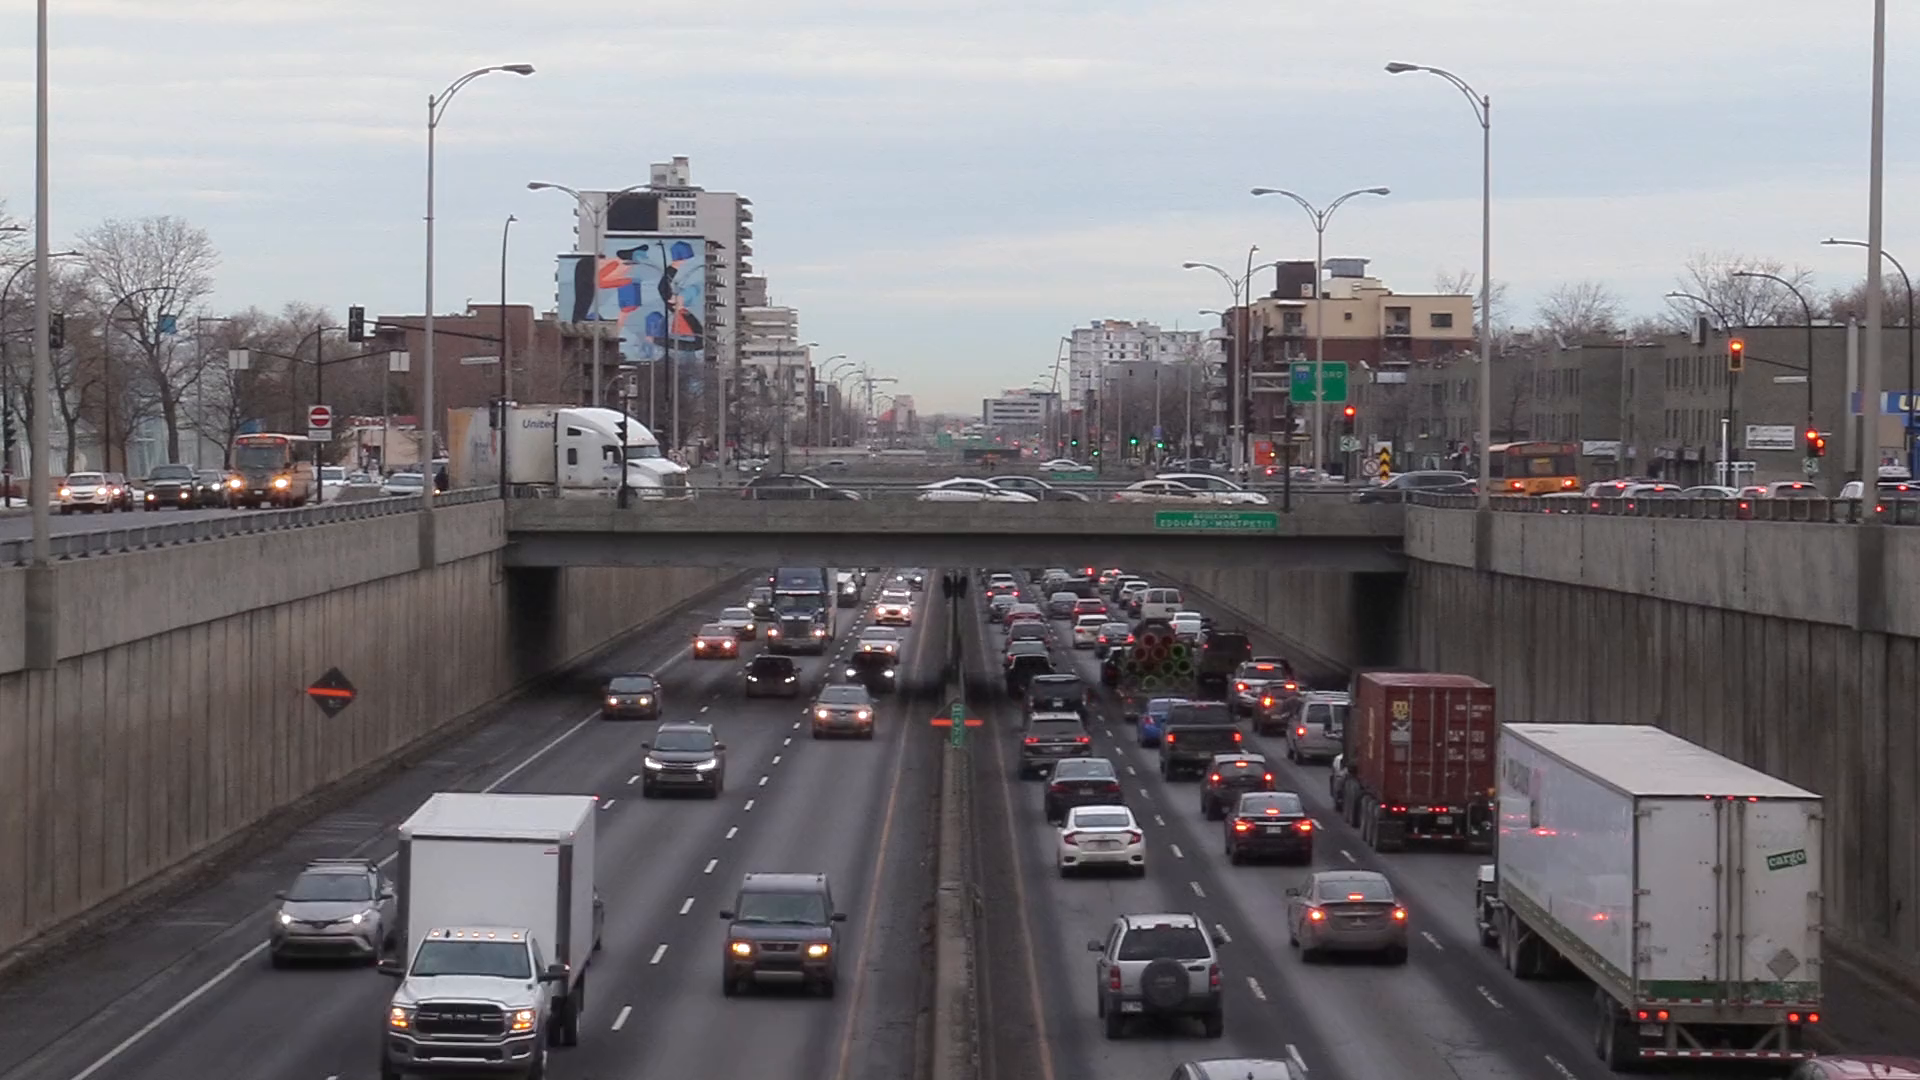

In [5]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT = Path("/content/drive/MyDrive/traffic-detection")
VIDEO_PATH = PROJECT / "data/videos/traffic.mp4"
OUTPUT_DIR = PROJECT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert VIDEO_PATH.is_file(), f"Video not found: {VIDEO_PATH}"

cap = cv2.VideoCapture(str(VIDEO_PATH))
success, frame = cap.read()
cap.release()

assert success, "Could not read the video."

from google.colab.patches import cv2_imshow
cv2_imshow(frame)